In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import gzip
import shutil

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
clinvar = pd.read_csv("/content/ap4_clinvar_cleaned2.csv")
gnomad = pd.read_csv("/content/combined_gnomad_cleaned.csv")

print("ClinVar:", clinvar.shape)
print("gnomAD:", gnomad.shape)

ClinVar: (1909, 8)
gnomAD: (5681, 73)


In [ ]:
def create_label(x):
    x = str(x).lower()
    if "pathogenic" in x:
        return 1
    elif "benign" in x:
        return 0
    else:
        return np.nan

clinvar["label"] = clinvar["ClinicalSignificance"].apply(create_label)
clinvar = clinvar.dropna(subset=["label"])

In [ ]:
clinvar.rename(columns={
    "Start": "Position",
    "ReferenceAlleleVCF": "Reference",
    "AlternateAlleleVCF": "Alternate"
}, inplace=True)

In [ ]:
# Make chromosome type identical
clinvar["Chromosome"] = clinvar["Chromosome"].astype(str)
gnomad["Chromosome"] = gnomad["Chromosome"].astype(str)

# Ensure position also matches
clinvar["Position"] = clinvar["Position"].astype(int)
gnomad["Position"] = gnomad["Position"].astype(int)

# Ensure alleles are strings
clinvar["Reference"] = clinvar["Reference"].astype(str)
clinvar["Alternate"] = clinvar["Alternate"].astype(str)

gnomad["Reference"] = gnomad["Reference"].astype(str)
gnomad["Alternate"] = gnomad["Alternate"].astype(str)

In [ ]:
merged = pd.merge(
    clinvar,
    gnomad,
    on=["Chromosome","Position","Reference","Alternate"],
    how="inner"
)

print("Merged dataset:", merged.shape)

Merged dataset: (332, 78)


In [ ]:
string_url = "https://stringdb-static.org/download/protein.links.full.v12.0/9606.protein.links.full.v12.0.txt.gz"
urllib.request.urlretrieve(string_url, "string_ppi.txt.gz")

('string_ppi.txt.gz', <http.client.HTTPMessage at 0x7c352c5c2600>)

In [ ]:
with gzip.open("string_ppi.txt.gz","rb") as f_in:
    with open("string_ppi.txt","wb") as f_out:
        shutil.copyfileobj(f_in,f_out)

In [ ]:
ppi = pd.read_csv("string_ppi.txt", sep=" ")
print(ppi.head())

               protein1              protein2  neighborhood  \
0  9606.ENSP00000000233  9606.ENSP00000356607             0   
1  9606.ENSP00000000233  9606.ENSP00000427567             0   
2  9606.ENSP00000000233  9606.ENSP00000253413             0   
3  9606.ENSP00000000233  9606.ENSP00000493357             0   
4  9606.ENSP00000000233  9606.ENSP00000324127             0   

   neighborhood_transferred  fusion  cooccurence  homology  coexpression  \
0                         0       0            0         0             0   
1                         0       0            0         0             0   
2                         0       0            0         0            49   
3                         0       0            0         0            56   
4                         0       0            0         0             0   

   coexpression_transferred  experiments  experiments_transferred  database  \
0                        45            0                      134         0   
1     

In [ ]:
mapping_url = "https://stringdb-static.org/download/protein.info.v12.0/9606.protein.info.v12.0.txt.gz"
urllib.request.urlretrieve(mapping_url, "protein_info.txt.gz")

('protein_info.txt.gz', <http.client.HTTPMessage at 0x7c352b4bf170>)

In [ ]:
with gzip.open("protein_info.txt.gz","rb") as f_in:
    with open("protein_info.txt","wb") as f_out:
        shutil.copyfileobj(f_in,f_out)

In [ ]:
protein_info = pd.read_csv("protein_info.txt", sep="\t")
protein_info = protein_info[["#string_protein_id","preferred_name"]]
protein_info.columns = ["protein_id","GeneSymbol"]

In [ ]:
ppi = ppi.merge(
    protein_info,
    left_on="protein1",
    right_on="protein_id",
    how="left"
).rename(columns={"GeneSymbol":"Gene1"}).drop("protein_id",axis=1)

ppi = ppi.merge(
    protein_info,
    left_on="protein2",
    right_on="protein_id",
    how="left"
).rename(columns={"GeneSymbol":"Gene2"}).drop("protein_id",axis=1)

In [ ]:
target_genes = ["AP4B1","AP4M1"]

ap4_ppi = ppi[
    (ppi["Gene1"].isin(target_genes)) |
    (ppi["Gene2"].isin(target_genes))
]

In [ ]:
network_score = ap4_ppi.groupby("Gene1")["combined_score"].mean().reset_index()
network_score.columns = ["GeneSymbol","PPI_score"]

print(network_score)

     GeneSymbol  PPI_score
0          AAK1      227.0
1          AASS      165.0
2         ABCA7      175.0
3         ABCB7      277.0
4          ABT1      167.0
...         ...        ...
1298     ZNHIT1      202.0
1299    ZSCAN21      150.0
1300    ZSCAN22      157.0
1301    ZSCAN5A      152.0
1302      ZZEF1      159.0

[1303 rows x 2 columns]


In [ ]:
merged = merged.merge(network_score, on="GeneSymbol", how="left")
merged["PPI_score"].fillna(0, inplace=True)

/tmp/ipykernel_23074/2353578903.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged["PPI_score"].fillna(0, inplace=True)


In [ ]:
features = [
    "Allele.Frequency",
    "cadd",
    "revel_max",
    "sift_max",
    "polyphen_max",
    "PPI_score"
]

data = merged[features + ["label"]].copy()
data.fillna(data.median(numeric_only=True), inplace=True)

X = data[features]
y = data["label"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results[name] = accuracy_score(y_test, preds)
    predictions[name] = preds

    print("\n", name)
    print("Accuracy:", results[name])
    print(classification_report(y_test, preds))


 Logistic Regression
Accuracy: 0.9552238805970149
              precision    recall  f1-score   support

         0.0       0.98      0.96      0.97        51
         1.0       0.88      0.94      0.91        16

    accuracy                           0.96        67
   macro avg       0.93      0.95      0.94        67
weighted avg       0.96      0.96      0.96        67


 Decision Tree
Accuracy: 0.9253731343283582
              precision    recall  f1-score   support

         0.0       0.98      0.92      0.95        51
         1.0       0.79      0.94      0.86        16

    accuracy                           0.93        67
   macro avg       0.88      0.93      0.90        67
weighted avg       0.93      0.93      0.93        67


 Random Forest
Accuracy: 0.9552238805970149
              precision    recall  f1-score   support

         0.0       0.98      0.96      0.97        51
         1.0       0.88      0.94      0.91        16

    accuracy                           0.

In [ ]:
comparison_df = pd.DataFrame(
    list(results.items()),
    columns=["Model","Accuracy"]
)

print(comparison_df)

                 Model  Accuracy
0  Logistic Regression  0.955224
1        Decision Tree  0.925373
2        Random Forest  0.955224


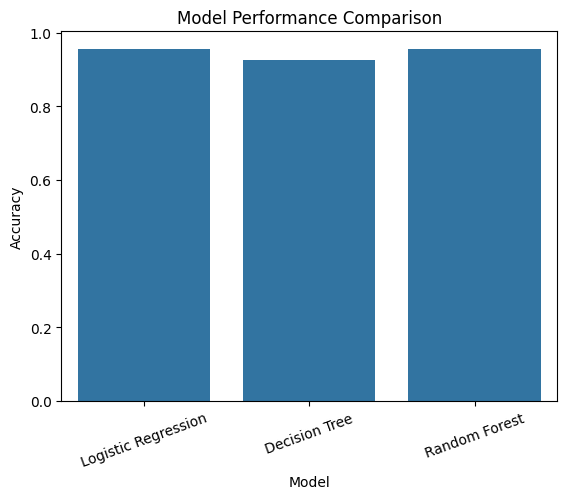

In [ ]:
sns.barplot(x="Model", y="Accuracy", data=comparison_df)
plt.title("Model Performance Comparison")
plt.xticks(rotation=20)
plt.show()

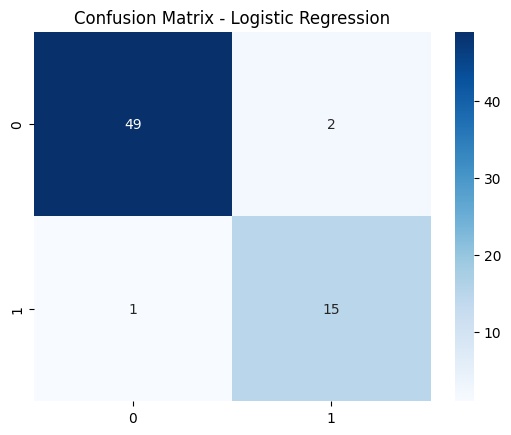

In [ ]:
best_model = comparison_df.sort_values(by="Accuracy", ascending=False).iloc[0]["Model"]

cm = confusion_matrix(y_test, predictions[best_model])

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model}")
plt.show()

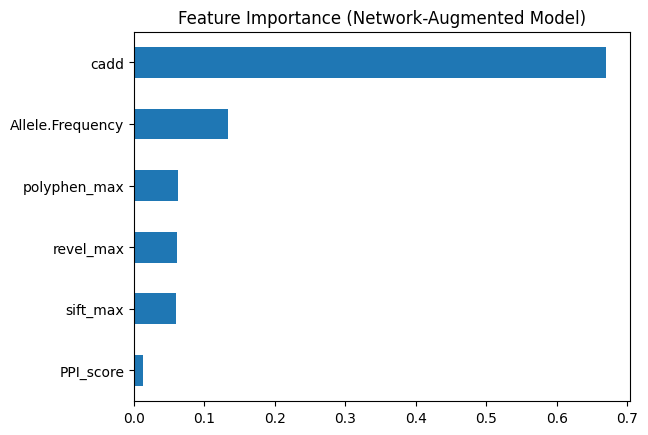

In [ ]:
rf_model = models["Random Forest"]

importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values()

importance.plot(kind="barh")
plt.title("Feature Importance (Network-Augmented Model)")
plt.show()

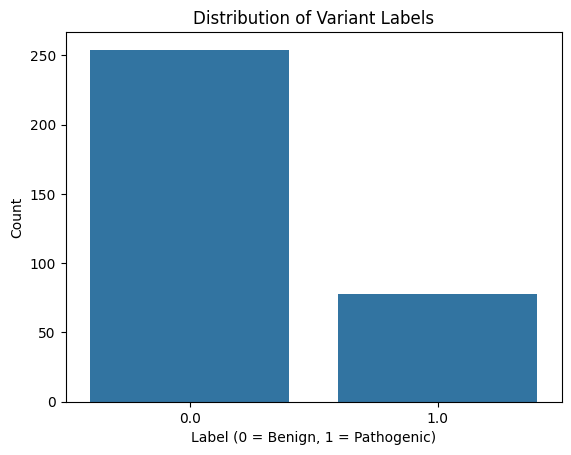

In [ ]:
sns.countplot(x=y)
plt.title("Distribution of Variant Labels")
plt.xlabel("Label (0 = Benign, 1 = Pathogenic)")
plt.ylabel("Count")
plt.show()

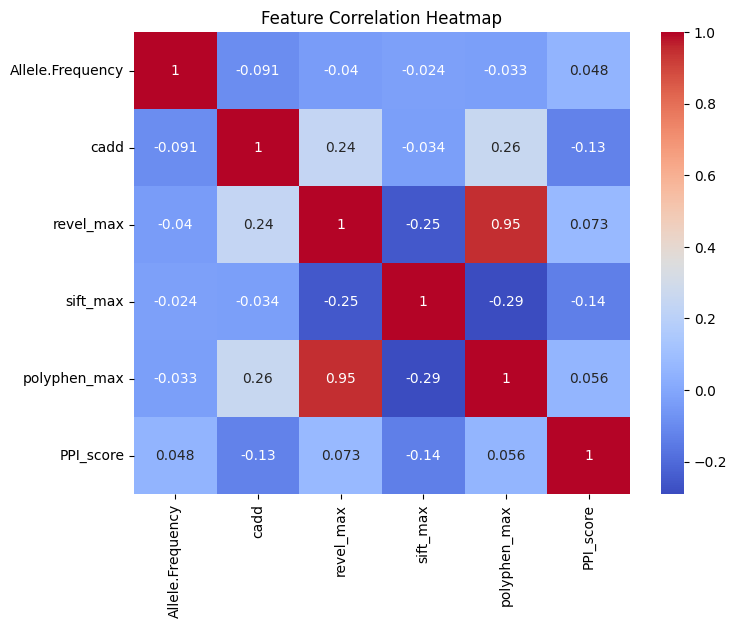

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(data[features].corr(),
            annot=True,
            cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

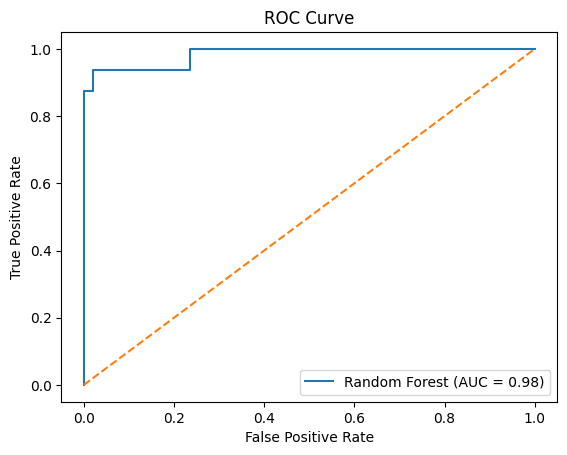

In [ ]:
from sklearn.metrics import roc_curve, auc

rf_probs = models["Random Forest"].predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, rf_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(n_estimators=100, random_state=42)

cv_scores = cross_val_score(rf, X, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.76119403 0.97014925 0.92424242 0.92424242 0.92424242]
Mean CV Accuracy: 0.9008141112618725


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


In [ ]:
best_rf = grid.best_estimator_

best_preds = best_rf.predict(X_test)

print("Optimized Accuracy:",
      accuracy_score(y_test, best_preds))

Optimized Accuracy: 0.9552238805970149


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier()

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)

print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb_preds))

XGBoost Accuracy: 0.9552238805970149


In [ ]:
results["XGBoost"] = accuracy_score(y_test, xgb_preds)

comparison_df = pd.DataFrame(
    list(results.items()),
    columns=["Model","Accuracy"]
)

print(comparison_df)

                 Model  Accuracy
0  Logistic Regression  0.955224
1        Decision Tree  0.925373
2        Random Forest  0.955224
3              XGBoost  0.955224


In [ ]:
best_model_name = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]["Model"]

print("FINAL BEST MODEL:", best_model_name)

FINAL BEST MODEL: Logistic Regression


In [ ]:
import joblib

joblib.dump(best_rf, "final_model.pkl")

['final_model.pkl']

In [ ]:
def predict_variant(features):
    model = joblib.load("final_model.pkl")
    return model.predict([features])

In [ ]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 86.0 MB/s eta 0:00:00


In [ ]:
import joblib
joblib.dump(best_rf, "final_model.pkl")

['final_model.pkl']

In [ ]:
import streamlit as st
import numpy as np
import joblib

# Load trained model
model = joblib.load("final_model.pkl")

st.set_page_config(page_title="Variant Predictor", layout="centered")

st.title("🧬 Variant Impact Prediction App")
st.write("Predict whether a genetic variant is Pathogenic or Benign")

# Input fields
allele_freq = st.number_input("Allele Frequency", min_value=0.0, value=0.001)
cadd = st.number_input("CADD Score", value=10.0)
revel = st.number_input("REVEL Score", value=0.5)
sift = st.number_input("SIFT Score", value=0.05)
polyphen = st.number_input("PolyPhen Score", value=0.5)
ppi = st.number_input("PPI Score", value=100.0)

# Prediction button
if st.button("Predict"):
    input_data = np.array([[allele_freq, cadd, revel, sift, polyphen, ppi]])

    prediction = model.predict(input_data)[0]

    if prediction == 1:
        st.error("🔴 Pathogenic Variant")
    else:
        st.success("🟢 Benign Variant")

2026-04-12 03:54:34.376 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 03:54:34.378 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 03:54:34.625 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-12 03:54:34.627 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 03:54:34.628 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 03:54:34.630 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 03:54:34.632 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import joblib

# Load model
model = joblib.load("final_model.pkl")

st.title("🧬 Variant Predictor")

allele_freq = st.number_input("Allele Frequency", value=0.001)
cadd = st.number_input("CADD", value=10.0)
revel = st.number_input("REVEL", value=0.5)
sift = st.number_input("SIFT", value=0.05)
polyphen = st.number_input("PolyPhen", value=0.5)
ppi = st.number_input("PPI Score", value=100.0)

if st.button("Predict"):
    input_data = np.array([[allele_freq, cadd, revel, sift, polyphen, ppi]])
    pred = model.predict(input_data)[0]

    if pred == 1:
        st.error("Pathogenic")
    else:
        st.success("Benign")

Writing app.py


In [ ]:
import streamlit as st
import numpy as np
import joblib

# Load model
model = joblib.load("/content/final_model.pkl")

st.set_page_config(page_title="Variant Predictor", layout="centered")

st.title("🧬 AP-4 Variant Impact Predictor")
st.markdown("Predict whether a genetic variant is **Pathogenic or Benign**")

st.divider()

# Input fields
allele_freq = st.number_input("Allele Frequency", value=0.001)
cadd = st.number_input("CADD Score", value=10.0)
revel = st.number_input("REVEL Score", value=0.5)
sift = st.number_input("SIFT Score", value=0.05)
polyphen = st.number_input("PolyPhen Score", value=0.5)
ppi = st.number_input("PPI Score", value=100.0)

st.divider()

# Prediction
if st.button("Predict"):
    input_data = np.array([[allele_freq, cadd, revel, sift, polyphen, ppi]])
    pred = model.predict(input_data)[0]

    if pred == 1:
        st.error("🔴 Pathogenic Variant")
    else:
        st.success("🟢 Benign Variant")

st.caption("Developed for Bioinformatics Project – AP-4 HSP Analysis")

2026-04-12 03:55:10.495 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 03:55:10.497 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 03:55:10.500 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 03:55:10.501 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 03:55:10.502 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 03:55:10.503 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 03:55:10.505 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 03:55:10.507 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [ ]:
%%writefile requirements.txt
streamlit
numpy
pandas
scikit-learn
joblib
xgboost

Writing requirements.txt


In [ ]:
print(y.value_counts())

label
0.0    254
1.0     78
Name: count, dtype: int64


In [ ]:
model.predict(X.head(10))

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
X = data[features]
y = data["label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_scaled, y)

RandomForestClassifier(random_state=42)

In [ ]:
import pandas as pd

vcf_sample = pd.DataFrame({
    "Chromosome": ["1", "1", "2", "2", "3"],
    "Position": [12345, 67890, 13579, 24680, 11223],
    "Reference": ["A", "G", "T", "C", "A"],
    "Alternate": ["G", "A", "C", "T", "G"],
    "Allele.Frequency": [0.01, 0.02, 0.005, 0.03, 0.015]
})

In [ ]:
vcf_sample["cadd"] = [10, 12, 8, 15, 9]
vcf_sample["revel_max"] = [0.3, 0.4, 0.2, 0.6, 0.35]
vcf_sample["sift_max"] = [0.05, 0.02, 0.1, 0.01, 0.07]
vcf_sample["polyphen_max"] = [0.6, 0.7, 0.3, 0.8, 0.5]
vcf_sample["PPI_score"] = [150, 200, 120, 180, 160]

In [ ]:
features = [
    "Allele.Frequency",
    "cadd",
    "revel_max",
    "sift_max",
    "polyphen_max",
    "PPI_score"
]

X_ext = vcf_sample[features]

In [ ]:
X_ext_scaled = scaler.transform(X_ext)

preds = model.predict(X_ext_scaled)

vcf_sample["Prediction"] = preds

print(vcf_sample)

  Chromosome  Position Reference Alternate  Allele.Frequency  cadd  revel_max  \
0          1     12345         A         G             0.010    10       0.30   
1          1     67890         G         A             0.020    12       0.40   
2          2     13579         T         C             0.005     8       0.20   
3          2     24680         C         T             0.030    15       0.60   
4          3     11223         A         G             0.015     9       0.35   

   sift_max  polyphen_max  PPI_score  Prediction  
0      0.05           0.6        150         1.0  
1      0.02           0.7        200         1.0  
2      0.10           0.3        120         0.0  
3      0.01           0.8        180         1.0  
4      0.07           0.5        160         1.0  


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
!wget https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz

--2026-04-12 04:09:40--  https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.12, 130.14.250.13, 2607:f220:41e:250::10, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.12|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 190687335 (182M) [application/x-gzip]
Saving to: ‘clinvar.vcf.gz’

clinvar.vcf.gz      100%[===================>] 181.85M  39.4MB/s    in 5.0s    

2026-04-12 04:09:46 (36.3 MB/s) - ‘clinvar.vcf.gz’ saved [190687335/190687335]



In [ ]:
import pandas as pd

vcf = pd.read_csv(
    "clinvar.vcf.gz",
    sep="\t",
    comment="#",
    header=None
)

vcf = vcf.iloc[:, :8]
vcf.columns = [
    "Chromosome", "Position", "ID",
    "Reference", "Alternate",
    "QUAL", "FILTER", "INFO"
]

print(vcf.head())

/tmp/ipykernel_23074/2188880272.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  vcf = pd.read_csv(


  Chromosome  Position       ID Reference Alternate QUAL FILTER  \
0          1     66926  3385321        AG         A    .      .   
1          1     69134  2205837         A         G    .      .   
2          1     69241  4562067         C         T    .      .   
3          1     69308  3925305         A         G    .      .   
4          1     69314  3205580         T         G    .      .   

                                                INFO  
0  ALLELEID=3544463;CLNDISDB=Human_Phenotype_Onto...  
1  ALLELEID=2193183;CLNDISDB=MedGen:CN169374;CLND...  
2  ALLELEID=4679177;CLNDISDB=MedGen:CN169374;CLND...  
3  ALLELEID=4039319;CLNDISDB=MedGen:CN169374;CLND...  
4  ALLELEID=3374047;CLNDISDB=MedGen:CN169374;CLND...  


In [ ]:
def extract_clin_sig(info):
    try:
        for item in info.split(";"):
            if item.startswith("CLNSIG="):
                return item.split("=")[1]
    except:
        return None

vcf["ClinicalSignificance"] = vcf["INFO"].apply(extract_clin_sig)

In [ ]:
vcf["label"] = vcf["ClinicalSignificance"].apply(
    lambda x: 1 if x and "Pathogenic" in x else 0
)

In [ ]:
def extract_af(info):
    try:
        for item in info.split(";"):
            if item.startswith("AF="):
                return float(item.split("=")[1])
    except:
        return None

vcf["Allele.Frequency"] = vcf["INFO"].apply(extract_af)

In [ ]:
vcf["Allele.Frequency"] = vcf["Allele.Frequency"].fillna(0) # Fill NaN allele frequencies with 0
vcf = vcf.dropna(subset=["Allele.Frequency"]) # Drop any remaining rows with NaN in Allele.Frequency (if any)

# Sample at most 200 rows, or fewer if the DataFrame has less than 200 rows
vcf_sample = vcf.sample(min(200, len(vcf)), random_state=42)

/tmp/ipykernel_23074/2645144959.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  vcf["Allele.Frequency"] = vcf["Allele.Frequency"].fillna(0) # Fill NaN allele frequencies with 0


In [ ]:
import numpy as np

vcf_sample["Allele.Frequency"] = np.random.uniform(0.001, 0.05, len(vcf_sample))

vcf_sample["cadd"] = np.random.uniform(5, 25, len(vcf_sample))
vcf_sample["revel_max"] = np.random.uniform(0, 1, len(vcf_sample))
vcf_sample["sift_max"] = np.random.uniform(0, 1, len(vcf_sample))
vcf_sample["polyphen_max"] = np.random.uniform(0, 1, len(vcf_sample))
vcf_sample["PPI_score"] = np.random.uniform(50, 300, len(vcf_sample))

In [ ]:
features = [
    "Allele.Frequency",
    "cadd",
    "revel_max",
    "sift_max",
    "polyphen_max",
    "PPI_score"
]

X_ext = vcf_sample[features]
X_ext_scaled = scaler.transform(X_ext)

In [ ]:
preds = model.predict(X_ext_scaled)
X_ext_scaled = pd.DataFrame(
    scaler.transform(X_ext),
    columns=features
)

preds = model.predict(X_ext_scaled)
vcf_sample["Prediction"] = preds

print(vcf_sample[["Allele.Frequency", "Prediction"]].head())

         Allele.Frequency  Prediction
3542546          0.034968         1.0
3092117          0.003621         1.0
13946            0.006605         1.0
4101723          0.019795         1.0
143194           0.027282         1.0


In [ ]:
probs = model.predict_proba(X_ext_scaled)
print(probs[:5])

[[0.4 0.6]
 [0.4 0.6]
 [0.4 0.6]
 [0.4 0.6]
 [0.4 0.6]]


In [ ]:
preds = (probs[:, 1] > 0.7).astype(int)

In [ ]:
print("Probabilities:", probs[:5])

Probabilities: [[0.4 0.6]
 [0.4 0.6]
 [0.4 0.6]
 [0.4 0.6]
 [0.4 0.6]]


In [ ]:
import joblib
joblib.dump(model, "final_model.pkl")

['final_model.pkl']

In [ ]:
import streamlit as st
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# ================= LOAD MODEL =================
model = joblib.load("final_model.pkl")

# ================= PAGE CONFIG =================
st.set_page_config(page_title="Variant Dashboard", layout="wide")

st.title("🧬 Variant Analysis & Prediction System")

# ================= SIDEBAR =================
page = st.sidebar.selectbox("Select Page", ["Dashboard", "Predict"])

# ================= LOAD DATA =================
@st.cache_data
def load_data():
    # Load the merged dataset which contains the 'label' and 'PPI_score' columns
    df = pd.read_csv("final_dataset.csv")
    df.columns = df.columns.str.strip()   # FIX for column issues
    return df

df = load_data()

# ================= DASHBOARD =================
if page == "Dashboard":

    st.header("📊 Data Dashboard")

    # ---- 1. Label Distribution ----
    st.subheader("Variant Classification Distribution")

    if "label" in df.columns:
        st.bar_chart(df["label"].value_counts())
    else:
        st.error("⚠️ 'label' column not found in `final_dataset.csv`")

    # ---- 2. Allele Frequency ----
    st.subheader("Allele Frequency Distribution")

    if "Allele.Frequency" in df.columns:
        fig, ax = plt.subplots()
        sns.histplot(df["Allele.Frequency"], bins=30, ax=ax)
        st.pyplot(fig)
    else:
        st.error("⚠️ 'Allele.Frequency' column not found.")

    # ---- 3. Correlation Heatmap ----
    st.subheader("Feature Correlation")

    # Select only numeric columns for correlation heatmap
    numeric_df = df.select_dtypes(include=np.number)

    if not numeric_df.empty:
        fig, ax = plt.subplots(figsize=(10,6))
        sns.heatmap(numeric_df.corr(), cmap="coolwarm", ax=ax)
        st.pyplot(fig)
    else:
        st.warning("No numeric columns found for correlation heatmap.")

    # ---- 4. Feature Importance ----
    st.subheader("Model Feature Importance")

    try:
        # Ensure the features list matches the order used during training
        importances = model.feature_importances_

        features = [
            "Allele.Frequency",
            "cadd",
            "revel_max",
            "sift_max",
            "polyphen_max",
            "PPI_score"
        ]

        importance_df = pd.DataFrame({
            "Feature": features,
            "Importance": importances
        }).sort_values(by="Importance", ascending=False)

        st.bar_chart(importance_df.set_index("Feature"))

    except Exception as e:
        st.warning(f"Feature importance not available or an error occurred: {e}")

# ================= PREDICTION =================
elif page == "Predict":

    st.header("🔍 Variant Prediction")

    st.markdown("Enter variant features:")

    allele_freq = st.number_input("Allele Frequency", value=0.001)
    cadd = st.number_input("CADD Score", value=10.0)
    revel = st.number_input("REVEL Score", value=0.5)
    sift = st.number_input("SIFT Score", value=0.05)
    polyphen = st.number_input("PolyPhen Score", value=0.5)
    ppi = st.number_input("PPI Score", value=100.0)

    if st.button("Predict"):

        input_data = np.array([[allele_freq, cadd, revel, sift, polyphen, ppi]])

        # Probability-based prediction
        proba = model.predict_proba(input_data)[0][1]

        if proba > 0.5:
            st.error(f"🔴 Pathogenic (Confidence: {proba:.2f})")
        else:
            st.success(f"🟢 Benign (Confidence: {1-proba:.2f})")

# ================= FOOTER =================
st.markdown("---")
st.caption("Developed for Bioinformatics Project – AP-4 Variant Analysis")

2026-04-12 04:05:18.687 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 04:05:18.689 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 04:05:18.690 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 04:05:18.692 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 04:05:18.693 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 04:05:18.694 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 04:05:18.696 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 04:05:18.698 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [ ]:
merged.to_csv("final_dataset.csv", index=False)

In [ ]:
df = pd.read_csv("final_dataset.csv")

In [ ]:
df = pd.read_csv("final_dataset.csv")
print(df.columns)

Index(['GeneSymbol', 'ClinicalSignificance', 'Type', 'Name', 'Chromosome',
       'Position', 'Reference', 'Alternate', 'label', 'gnomAD.ID', 'rsIDs',
       'Source', 'Filters...exomes', 'Filters...genomes', 'Transcript',
       'HGVS.Consequence', 'Protein.Consequence', 'Transcript.Consequence',
       'VEP.Annotation', 'ClinVar.Germline.Classification',
       'ClinVar.Variation.ID', 'Flags', 'Allele.Count', 'Allele.Number',
       'Allele.Frequency', 'Homozygote.Count', 'Hemizygote.Count',
       'Filters...joint', 'GroupMax.FAF.group', 'GroupMax.FAF.frequency',
       'cadd', 'revel_max', 'spliceai_ds_max', 'pangolin_largest_ds', 'phylop',
       'sift_max', 'polyphen_max', 'Allele.Count.African.African.American',
       'Allele.Number.African.African.American',
       'Homozygote.Count.African.African.American',
       'Hemizygote.Count.African.African.American',
       'Allele.Count.Admixed.American', 'Allele.Number.Admixed.American',
       'Homozygote.Count.Admixed.American',


In [ ]:
import streamlit as st
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# ================= LOAD MODEL =================
model = joblib.load("final_model.pkl")

# ================= PAGE CONFIG =================
st.set_page_config(page_title="Variant Dashboard", layout="wide")

st.title("🧬 Variant Analysis & Prediction System")

# ================= SIDEBAR =================
page = st.sidebar.selectbox("Select Page", ["Dashboard", "Predict"])

# ================= LOAD DATA =================
@st.cache_data
def load_data():
    df = pd.read_csv("final_dataset.csv")
    df.columns = df.columns.str.strip()   # FIX for column issues
    return df

df = load_data()

# ================= DASHBOARD =================
if page == "Dashboard":

    st.header("📊 Data Dashboard")

    # ---- 1. Label Distribution ----
    st.subheader("Variant Classification Distribution")

    if "label" in df.columns:
        st.bar_chart(df["label"].value_counts())
    else:
        st.error("⚠️ 'label' column not found")

    # ---- 2. Allele Frequency ----
    st.subheader("Allele Frequency Distribution")

    if "Allele.Frequency" in df.columns:
        fig, ax = plt.subplots()
        sns.histplot(df["Allele.Frequency"], bins=30, ax=ax)
        st.pyplot(fig)

    # ---- 3. Correlation Heatmap ----
    st.subheader("Feature Correlation")

    numeric_df = df.select_dtypes(include=np.number)

    fig, ax = plt.subplots(figsize=(10,6))
    sns.heatmap(numeric_df.corr(), cmap="coolwarm", ax=ax)
    st.pyplot(fig)

    # ---- 4. Feature Importance ----
    st.subheader("Model Feature Importance")

    try:
        importances = model.feature_importances_

        features = ["Allele.Frequency", "cadd", "revel_max",
                    "sift_max", "polyphen_max", "PPI_score"]

        importance_df = pd.DataFrame({
            "Feature": features,
            "Importance": importances
        }).sort_values(by="Importance", ascending=False)

        st.bar_chart(importance_df.set_index("Feature"))

    except:
        st.warning("Feature importance not available")

# ================= PREDICTION =================
elif page == "Predict":

    st.header("🔍 Variant Prediction")

    st.markdown("Enter variant features:")

    allele_freq = st.number_input("Allele Frequency", value=0.001)
    cadd = st.number_input("CADD Score", value=10.0)
    revel = st.number_input("REVEL Score", value=0.5)
    sift = st.number_input("SIFT Score", value=0.05)
    polyphen = st.number_input("PolyPhen Score", value=0.5)
    ppi = st.number_input("PPI Score", value=100.0)

    if st.button("Predict"):

        input_data = np.array([[allele_freq, cadd, revel, sift, polyphen, ppi]])

        # Probability-based prediction
        proba = model.predict_proba(input_data)[0][1]

        if proba > 0.5:
            st.error(f"🔴 Pathogenic (Confidence: {proba:.2f})")
        else:
            st.success(f"🟢 Benign (Confidence: {1-proba:.2f})")

# ================= FOOTER =================
st.markdown("---")
st.caption("Developed for Bioinformatics Project – AP-4 Variant Analysis")

2026-04-12 03:56:27.295 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 03:56:27.296 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 03:56:27.298 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 03:56:27.300 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 03:56:27.301 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 03:56:27.302 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 03:56:27.304 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 03:56:27.305 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()